# SIGHTAI – Exploratory Data Analysis
**Tuberculosis Chest X-Ray Datasets: Montgomery + Shenzhen**

This notebook explores the two datasets used to train the SIGHTAI TB detection model:
- Class distribution (normal vs TB)
- Patient demographics (age, sex)
- Image characteristics (size, pixel statistics)
- Sample X-ray visualisation

In [1]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

import config
from data.pipeline import load_dataframe, split_dataframe

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## 1. Load Metadata

In [3]:
mont = pd.read_csv(config.MONTGOMERY_META)
shen = pd.read_csv(config.SHENZHEN_META)

print('Montgomery shape:', mont.shape)
print(mont.head(3))
print()
print('Shenzhen shape:', shen.shape)
print(shen.head(3))

Montgomery shape: (138, 4)
            study_id  age  gender findings
0  MCUCXR_0001_0.png   27  Female   normal
1  MCUCXR_0002_0.png   40  Female   normal
2  MCUCXR_0003_0.png   21  Female   normal

Shenzhen shape: (662, 4)
            study_id     sex  age findings
0  CHNCXR_0001_0.png    Male   45   normal
1  CHNCXR_0002_0.png    Male   63   normal
2  CHNCXR_0003_0.png  Female   48   normal


In [4]:
# Load combined DataFrame with binary labels
df = load_dataframe()
print(df.shape)
df.head()

Dataset loaded: 800 images | TB=394 | Normal=406
(800, 6)


,image_path,findings,age,sex,dataset,label
0,C:\Users\abena\Desktop\SIGHTAIGH\notebooks\..\...,normal,27,Female,montgomery,0
1,C:\Users\abena\Desktop\SIGHTAIGH\notebooks\..\...,normal,40,Female,montgomery,0
2,C:\Users\abena\Desktop\SIGHTAIGH\notebooks\..\...,normal,21,Female,montgomery,0
3,C:\Users\abena\Desktop\SIGHTAIGH\notebooks\..\...,normal,11,Female,montgomery,0
4,C:\Users\abena\Desktop\SIGHTAIGH\notebooks\..\...,normal,33,Male,montgomery,0


## 2. Class Distribution

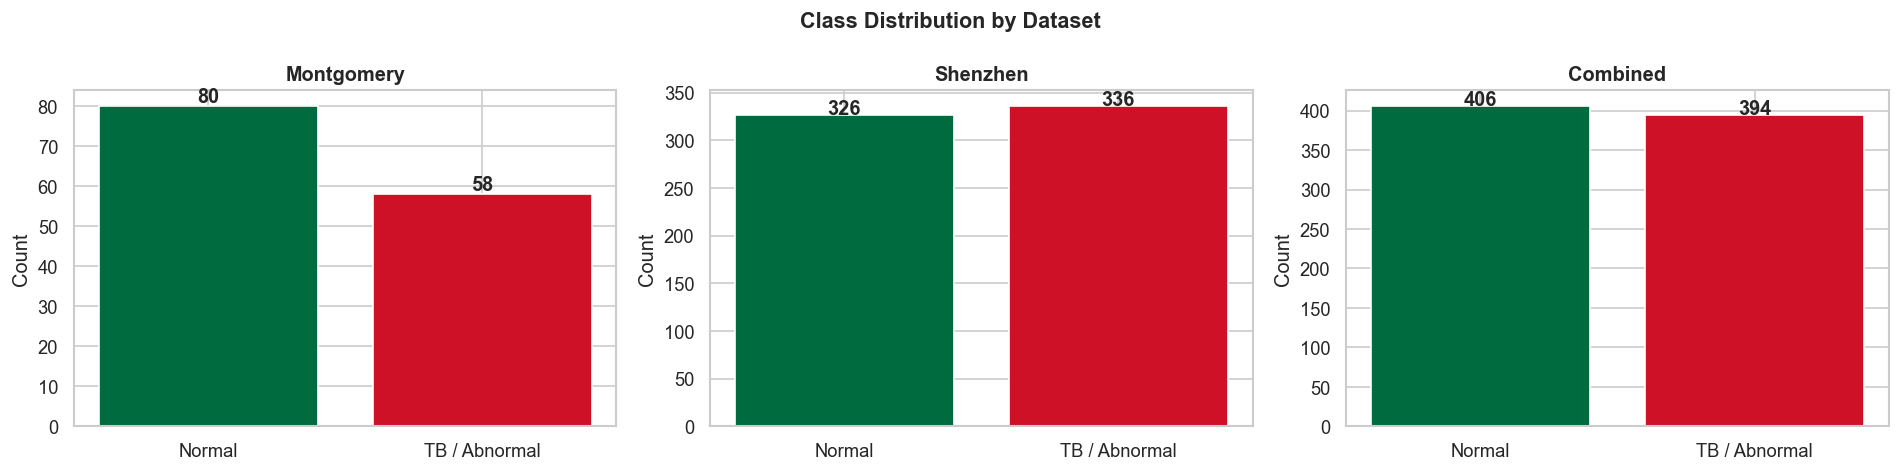


Class balance (combined):
label
Normal    0.5075
TB        0.4925


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Class Distribution by Dataset', fontsize=13, fontweight='bold')

label_names = {0: 'Normal', 1: 'TB / Abnormal'}
colors = ['#006B3F', '#CE1126']

for ax, (dataset, group) in zip(axes[:2], df.groupby('dataset')):
    counts = group['label'].value_counts().sort_index()
    bars = ax.bar([label_names[i] for i in counts.index], counts.values, color=colors)
    ax.set_title(dataset.capitalize(), fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', fontweight='bold')

# Combined
counts_all = df['label'].value_counts().sort_index()
bars = axes[2].bar([label_names[i] for i in counts_all.index], counts_all.values, color=colors)
axes[2].set_title('Combined', fontweight='bold')
axes[2].set_ylabel('Count')
for bar, val in zip(bars, counts_all.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClass balance (combined):')
print(df['label'].value_counts(normalize=True).rename({0:'Normal', 1:'TB'}).to_string())

## 3. Demographics – Age Distribution

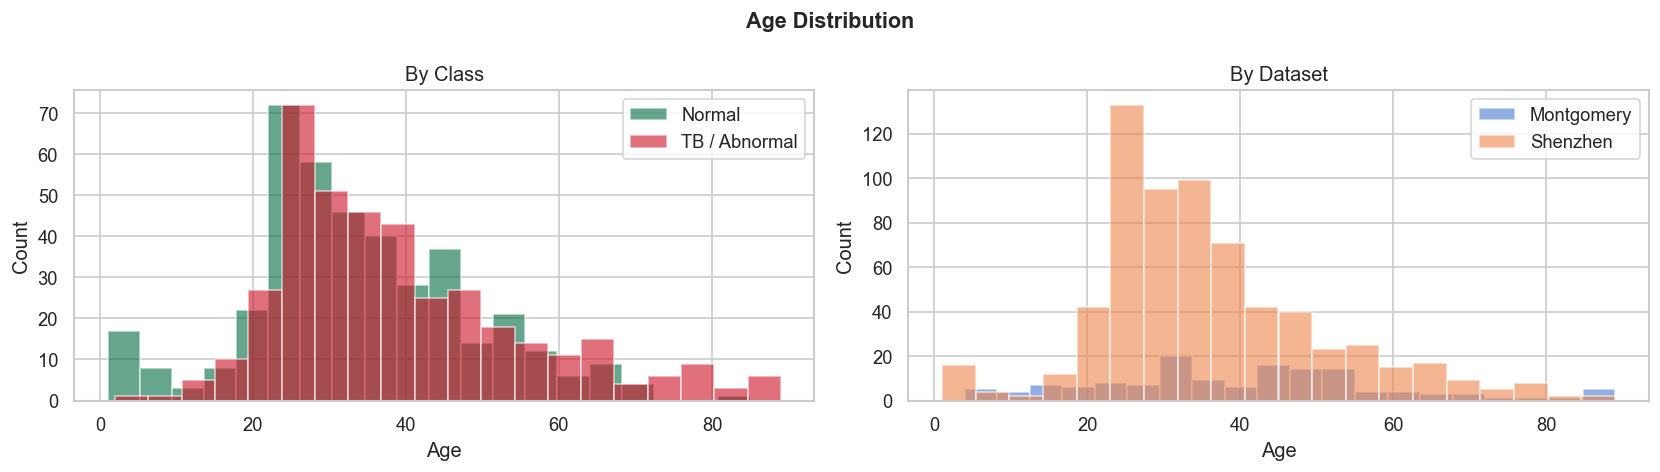

Age statistics:
               count       mean        std  min    25%   50%    75%   max
label                                                                    
Normal         406.0  33.551724  14.380063  1.0  25.00  32.0  43.00  85.0
TB / Abnormal  394.0  39.248731  16.227676  2.0  27.25  35.0  48.75  89.0


In [6]:
df_age = df.copy()
df_age['age'] = pd.to_numeric(df_age['age'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Age Distribution', fontsize=13, fontweight='bold')

# By label
for label, grp in df_age.groupby('label'):
    axes[0].hist(grp['age'].dropna(), bins=20, alpha=0.6,
                 label=label_names[label], color=colors[label])
axes[0].set_title('By Class')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# By dataset
for dataset, grp in df_age.groupby('dataset'):
    axes[1].hist(grp['age'].dropna(), bins=20, alpha=0.6, label=dataset.capitalize())
axes[1].set_title('By Dataset')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Age statistics:')
print(df_age.groupby('label')['age'].describe().rename(index=label_names))

## 4. Demographics – Sex Distribution

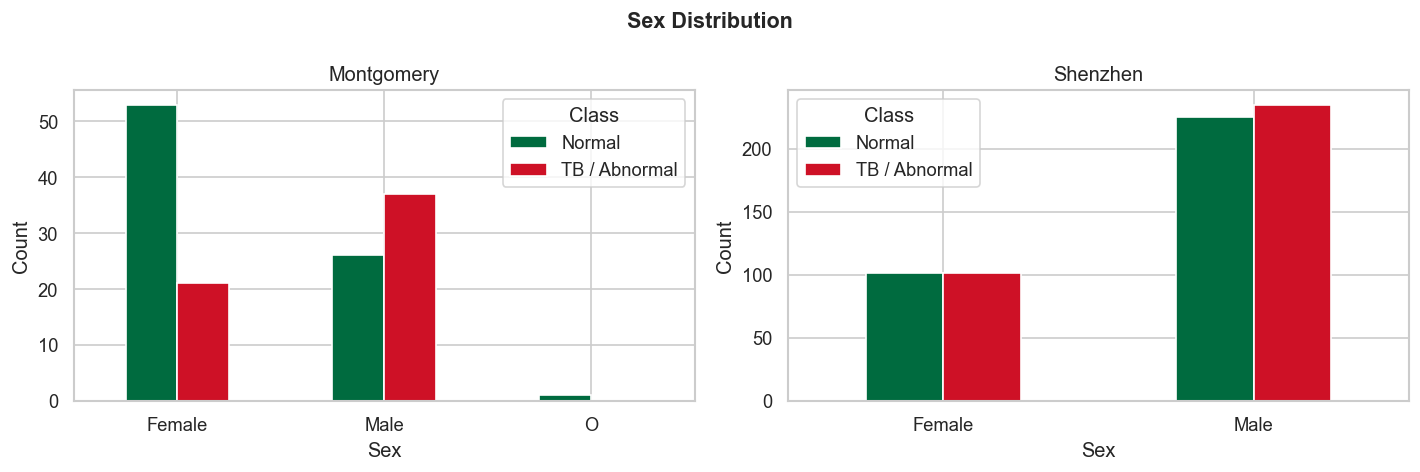

In [7]:
df['sex_clean'] = df['sex'].str.strip().str.capitalize()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sex Distribution', fontsize=13, fontweight='bold')

for ax, (dataset, grp) in zip(axes, df.groupby('dataset')):
    ct = pd.crosstab(grp['sex_clean'], grp['label'].map(label_names))
    ct.plot(kind='bar', ax=ax, color=colors, rot=0)
    ax.set_title(dataset.capitalize())
    ax.set_xlabel('Sex')
    ax.set_ylabel('Count')
    ax.legend(title='Class')

plt.tight_layout()
plt.show()

## 5. Image Size Analysis

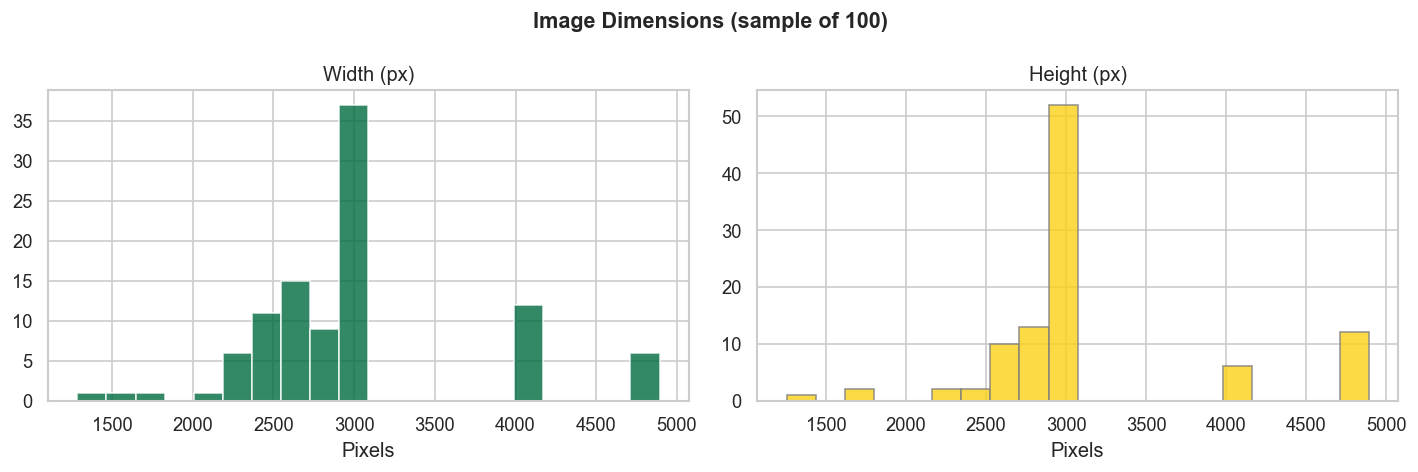

Width  — mean: 3006  min: 1286  max: 4892
Height — mean: 3136  min: 1252  max: 4892


In [8]:
widths, heights = [], []

sample = df.sample(min(100, len(df)), random_state=42)
for path in sample['image_path']:
    try:
        w, h = Image.open(path).size
        widths.append(w)
        heights.append(h)
    except Exception:
        pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Image Dimensions (sample of 100)', fontsize=13, fontweight='bold')

axes[0].hist(widths,  bins=20, color='#006B3F', alpha=0.8)
axes[0].set_title('Width (px)')
axes[0].set_xlabel('Pixels')

axes[1].hist(heights, bins=20, color='#FCD116', alpha=0.8, edgecolor='gray')
axes[1].set_title('Height (px)')
axes[1].set_xlabel('Pixels')

plt.tight_layout()
plt.show()

print(f'Width  — mean: {np.mean(widths):.0f}  min: {min(widths)}  max: {max(widths)}')
print(f'Height — mean: {np.mean(heights):.0f}  min: {min(heights)}  max: {max(heights)}')

## 6. Pixel Intensity Statistics

C:\Users\abena\AppData\Local\Temp\ipykernel_23556\2698493281.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pixel_df, x='class', y='mean', palette=['#006B3F','#CE1126'], ax=axes[0])
C:\Users\abena\AppData\Local\Temp\ipykernel_23556\2698493281.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pixel_df, x='class', y='std', palette=['#006B3F','#CE1126'], ax=axes[1])


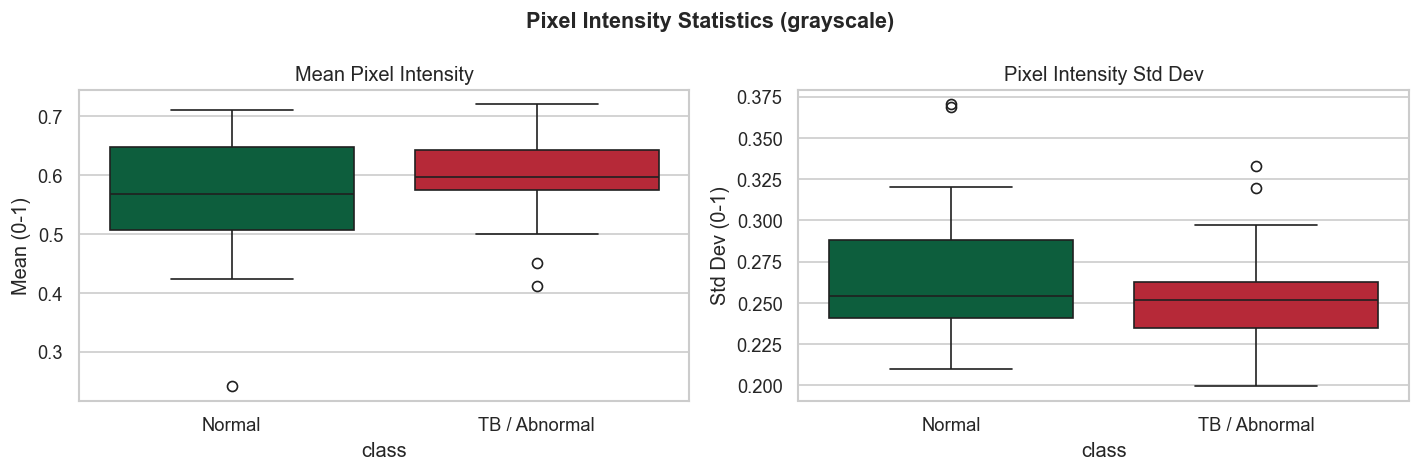

In [9]:
means, stds = [], []
label_col = []

sample2 = df.sample(min(60, len(df)), random_state=0)
for _, row in sample2.iterrows():
    try:
        arr = np.array(Image.open(row['image_path']).convert('L'), dtype=np.float32) / 255.0
        means.append(arr.mean())
        stds.append(arr.std())
        label_col.append(label_names[row['label']])
    except Exception:
        pass

pixel_df = pd.DataFrame({'mean': means, 'std': stds, 'class': label_col})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Pixel Intensity Statistics (grayscale)', fontsize=13, fontweight='bold')

sns.boxplot(data=pixel_df, x='class', y='mean', palette=['#006B3F','#CE1126'], ax=axes[0])
axes[0].set_title('Mean Pixel Intensity')
axes[0].set_ylabel('Mean (0-1)')

sns.boxplot(data=pixel_df, x='class', y='std', palette=['#006B3F','#CE1126'], ax=axes[1])
axes[1].set_title('Pixel Intensity Std Dev')
axes[1].set_ylabel('Std Dev (0-1)')

plt.tight_layout()
plt.show()

## 7. Sample X-Ray Images

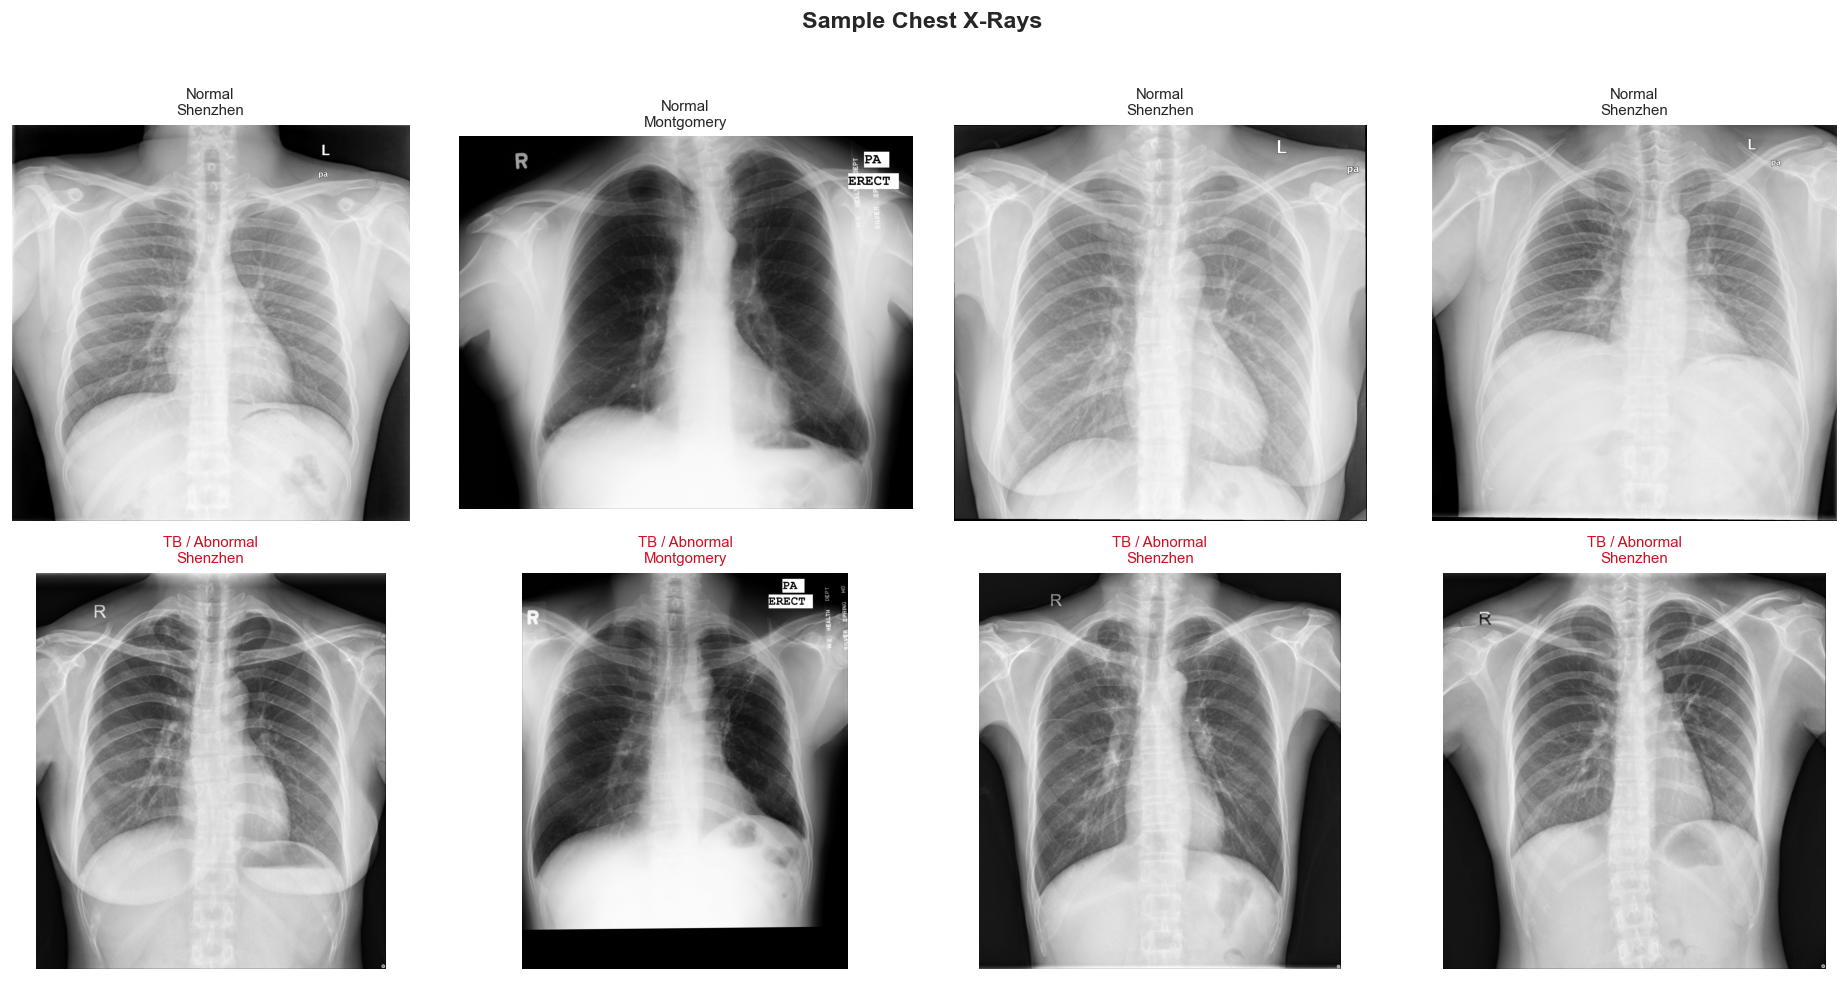

In [10]:
normal_samples = df[df['label'] == 0].sample(4, random_state=1)
tb_samples     = df[df['label'] == 1].sample(4, random_state=2)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sample Chest X-Rays', fontsize=14, fontweight='bold', y=1.02)

for i, (_, row) in enumerate(normal_samples.iterrows()):
    img = Image.open(row['image_path']).convert('L')
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"Normal\n{row['dataset'].capitalize()}", fontsize=9)
    axes[0, i].axis('off')

for i, (_, row) in enumerate(tb_samples.iterrows()):
    img = Image.open(row['image_path']).convert('L')
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].set_title(f"TB / Abnormal\n{row['dataset'].capitalize()}", fontsize=9, color='#CE1126')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 8. Average X-Ray per Class

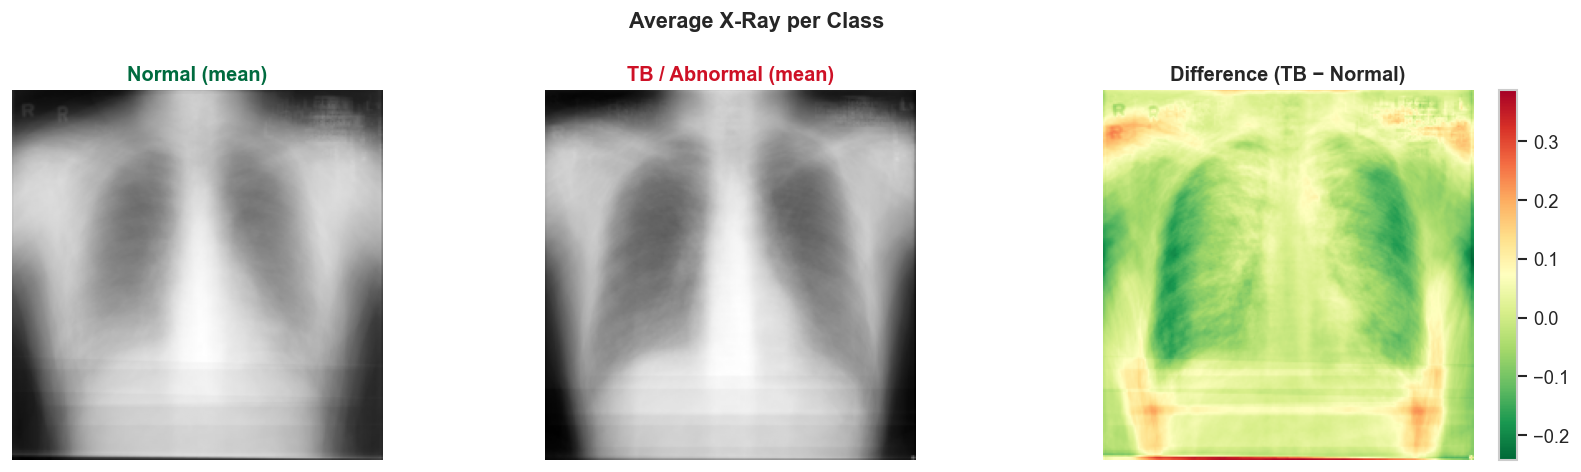

In [11]:
TARGET = (224, 224)

def mean_image(subset_df, n=40):
    sample = subset_df.sample(min(n, len(subset_df)), random_state=42)
    arrays = []
    for path in sample['image_path']:
        try:
            arr = np.array(Image.open(path).convert('L').resize(TARGET), dtype=np.float32) / 255.0
            arrays.append(arr)
        except Exception:
            pass
    return np.mean(arrays, axis=0)

avg_normal = mean_image(df[df['label'] == 0])
avg_tb     = mean_image(df[df['label'] == 1])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Average X-Ray per Class', fontsize=13, fontweight='bold')

axes[0].imshow(avg_normal, cmap='gray')
axes[0].set_title('Normal (mean)', color='#006B3F', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(avg_tb, cmap='gray')
axes[1].set_title('TB / Abnormal (mean)', color='#CE1126', fontweight='bold')
axes[1].axis('off')

diff = avg_tb - avg_normal
im = axes[2].imshow(diff, cmap='RdYlGn_r')
axes[2].set_title('Difference (TB − Normal)', fontweight='bold')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## 9. Train / Val / Test Split Summary

Split → train=559 | val=121 | test=120
Split  Total  Normal  TB  TB%
Train    559     284 275 49.2
  Val    121      61  60 49.6
 Test    120      61  59 49.2


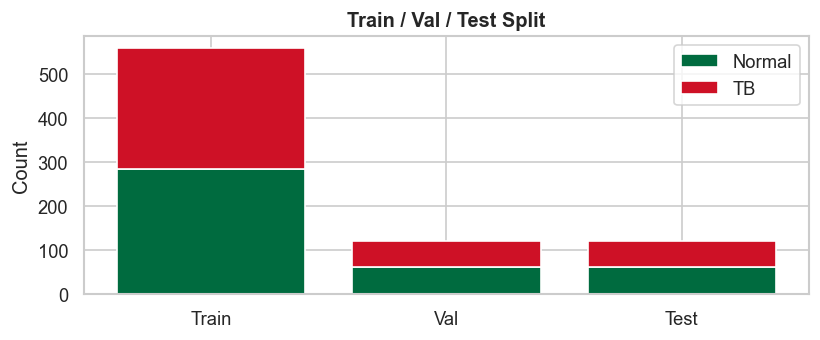

In [12]:
train_df, val_df, test_df = split_dataframe(df)

split_summary = pd.DataFrame({
    'Split':   ['Train', 'Val', 'Test'],
    'Total':   [len(train_df), len(val_df), len(test_df)],
    'Normal':  [(train_df['label']==0).sum(), (val_df['label']==0).sum(), (test_df['label']==0).sum()],
    'TB':      [(train_df['label']==1).sum(), (val_df['label']==1).sum(), (test_df['label']==1).sum()],
})
split_summary['TB%'] = (split_summary['TB'] / split_summary['Total'] * 100).round(1)
print(split_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
x = split_summary['Split']
ax.bar(x, split_summary['Normal'], label='Normal', color='#006B3F')
ax.bar(x, split_summary['TB'],     label='TB',     color='#CE1126',
       bottom=split_summary['Normal'])
ax.set_title('Train / Val / Test Split', fontweight='bold')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary

| Item | Value |
|---|---|
| Total images | 800 |
| Normal | 406 (50.8%) |
| TB / Abnormal | 394 (49.2%) |
| Datasets | Montgomery (138) + Shenzhen (662) |
| Input size (model) | 224 × 224 px |
| Train / Val / Test | ~70% / 15% / 15% stratified |

The dataset is **well-balanced** — no heavy class weighting needed, though the training script computes weights as a safeguard.  
Next step: run `python model/train.py` to train the EfficientNetB0 classifier.